# Pipeline d'Analyse de Transactions Bancaires - Détection de Fraude

Ce notebook présente un pipeline complet pour l'analyse des transactions bancaires et la détection de transactions suspectes ('fraude') à l'aide de plusieurs modèles de Machine Learning. Le processus inclut le chargement des données, le prétraitement, l'ingénierie des caractéristiques, l'entraînement et l'évaluation de différents modèles de classification. Toutes les colonnes originales sont conservées dans le DataFrame principal (`df`), mais seules les caractéristiques pertinentes sont utilisées pour l'entraînement des modèles.

## 1. Importations Nécessaires

In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, mean_squared_error, r2_score

## 2. Chargement des Données

Nous allons monter Google Drive pour accéder au fichier CSV de transactions bancaires et le charger dans un DataFrame pandas.

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Bank_transaction_scenario1.csv'
df = pd.read_csv(file_path)

print("Aperçu des 5 premières lignes du DataFrame original:")
display(df.head())
print("\nInformations générales sur le DataFrame original:")
df.info()
print("\nStatistiques descriptives du DataFrame original:")
display(df.describe(include='all'))
print("\nNombre de valeurs manquantes par colonne dans le DataFrame original:")
display(df.isnull().sum())

Aperçu des 5 premières lignes du DataFrame original:


,ID Clients;Numero de compte;Identifiant operation;Type de transaction;Status operation;Localisation;Date;Montant;Target
0,1023;851032.0;TR208/1145;Paiement en ligne;Ech...
1,543;85453.0;TR107/0124;ATM;Echoué;Tambacounda;...
2,1013;851301.0;TR205/00196;Paiement électroniqu...
3,10360;8501036.0;TR216/00239;ATM;Validé;Kaolack...
4,1022;851202.0;TR208/0023;ATM;Validé;Ziguinchor...



Informations générales sur le DataFrame original:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5382 entries, 0 to 5381
Data columns (total 1 columns):
 #   Column                                                                                                                   Non-Null Count  Dtype 
---  ------                                                                                                                   --------------  ----- 
 0   ID Clients;Numero de compte;Identifiant operation;Type de transaction;Status operation;Localisation;Date;Montant;Target  5382 non-null   object
dtypes: object(1)
memory usage: 42.2+ KB

Statistiques descriptives du DataFrame original:


,ID Clients;Numero de compte;Identifiant operation;Type de transaction;Status operation;Localisation;Date;Montant;Target
count,5382
unique,5382
top,507;85705.0;TR2/00510033;Paiement en ligne;Val...
freq,1



Nombre de valeurs manquantes par colonne dans le DataFrame original:


,0
ID Clients;Numero de compte;Identifiant operation;Type de transaction;Status operation;Localisation;Date;Montant;Target,0


## 3. Prétraitement des Données

Cette section gère la transformation des données brutes en un format adapté à l'entraînement des modèles de Machine Learning. Cela inclut la division des colonnes combinées, la conversion des types de données, l'ingénierie de nouvelles caractéristiques et l'encodage des variables catégorielles. Toutes les colonnes originales sont conservées, même si elles ne sont pas directement utilisées comme caractéristiques pour le modèle.

In [33]:
# Diviser la colonne combinée en plusieurs colonnes
df_split = df['ID Clients;Numero de compte;Identifiant operation;Type de transaction;Status operation;Localisation;Date;Montant;Target'].str.split(';', expand=True)
df_split.columns = ['ID Clients', 'Numero de compte', 'Identifiant operation', 'Type de transaction', 'Status operation', 'Localisation', 'Date', 'Montant', 'Target']
df = df_split.copy()

print("Aperçu des données après division des colonnes:")
display(df.head())

Aperçu des données après division des colonnes:


,ID Clients,Numero de compte,Identifiant operation,Type de transaction,Status operation,Localisation,Date,Montant,Target
0,1023,851032.0,TR208/1145,Paiement en ligne,Echoué,Kaolack,2025-02-10 22:20:00,45000.0,Normal
1,543,85453.0,TR107/0124,ATM,Echoué,Tambacounda,2025-02-10 17:00:00,18000.0,Suspect
2,1013,851301.0,TR205/00196,Paiement électronique,Validé,Thiès,2025-02-10 03:30:00,200000.0,Normal
3,10360,8501036.0,TR216/00239,ATM,Validé,Kaolack,2025-02-09 09:00:00,29000.0,Normal
4,1022,851202.0,TR208/0023,ATM,Validé,Ziguinchor,2025-02-08 15:55:00,14000.0,Normal


In [34]:
# Convertir les colonnes numériques
df['Numero de compte'] = pd.to_numeric(df['Numero de compte'], errors='coerce')
df['Montant'] = pd.to_numeric(df['Montant'], errors='coerce')
df['ID Clients'] = pd.to_numeric(df['ID Clients'], errors='coerce')

# Encoder la colonne 'Target' (variable dépendante) en numérique
df['Target'] = df['Target'].map({'Normal': 0, 'Suspect': 1})

print("Types de données après conversion initiale:")
df.info()

Types de données après conversion initiale:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5382 entries, 0 to 5381
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID Clients             5382 non-null   int64  
 1   Numero de compte       5382 non-null   float64
 2   Identifiant operation  5382 non-null   object 
 3   Type de transaction    5382 non-null   object 
 4   Status operation       5382 non-null   object 
 5   Localisation           5382 non-null   object 
 6   Date                   5382 non-null   object 
 7   Montant                5382 non-null   float64
 8   Target                 5184 non-null   float64
dtypes: float64(3), int64(1), object(5)
memory usage: 378.6+ KB


In [35]:
# Ingénierie des caractéristiques temporelles à partir de la colonne 'Date'
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['DayOfWeek'] = df['Date'].dt.dayofweek # Lundi=0, Dimanche=6
df['Month'] = df['Date'].dt.month

print("Aperçu des données avec les nouvelles caractéristiques temporelles (la colonne 'Date' originale est conservée) :")
display(df.head())

Aperçu des données avec les nouvelles caractéristiques temporelles (la colonne 'Date' originale est conservée) :


,ID Clients,Numero de compte,Identifiant operation,Type de transaction,Status operation,Localisation,Date,Montant,Target,DayOfWeek,Month
0,1023,851032.0,TR208/1145,Paiement en ligne,Echoué,Kaolack,2025-02-10 22:20:00,45000.0,0.0,0,2
1,543,85453.0,TR107/0124,ATM,Echoué,Tambacounda,2025-02-10 17:00:00,18000.0,1.0,0,2
2,1013,851301.0,TR205/00196,Paiement électronique,Validé,Thiès,2025-02-10 03:30:00,200000.0,0.0,0,2
3,10360,8501036.0,TR216/00239,ATM,Validé,Kaolack,2025-02-09 09:00:00,29000.0,0.0,6,2
4,1022,851202.0,TR208/0023,ATM,Validé,Ziguinchor,2025-02-08 15:55:00,14000.0,0.0,5,2


In [36]:
# Gérer les valeurs manquantes en supprimant les lignes concernées
# Cela garantit la qualité des données pour l'entraînement du modèle.
initial_rows = df.shape[0]
df = df.dropna()
print(f"Nombre de lignes initiales : {initial_rows}")
print(f"Nombre de lignes après suppression des NaN : {df.shape[0]}")
print("Nombre de valeurs manquantes après nettoyage final:")
display(df.isnull().sum())

Nombre de lignes initiales : 5382
Nombre de lignes après suppression des NaN : 5184
Nombre de valeurs manquantes après nettoyage final:


,0
ID Clients,0
Numero de compte,0
Identifiant operation,0
Type de transaction,0
Status operation,0
Localisation,0
Date,0
Montant,0
Target,0
DayOfWeek,0


### Encodage des Caractéristiques Catégorielles

Nous utilisons l'encodage One-Hot pour les variables catégorielles afin de les rendre compréhensibles par les modèles de Machine Learning. Les colonnes catégorielles originales seront remplacées par leurs versions encodées.

In [37]:
categorical_cols = ['Type de transaction', 'Status operation', 'Localisation']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Aperçu des données après encodage One-Hot des caractéristiques catégorielles:")
display(df.head())
print("Informations générales sur le DataFrame final:")
df.info()

Aperçu des données après encodage One-Hot des caractéristiques catégorielles:


,ID Clients,Numero de compte,Identifiant operation,Date,Montant,Target,DayOfWeek,Month,Type de transaction_Paiement en ligne,Type de transaction_Paiement électronique,...,Localisation_Saint-Louis,Localisation_Saloum,Localisation_Sédhiou,Localisation_Tambacounda,Localisation_Thiès,Localisation_Tivaouane,Localisation_Touba,Localisation_Toubacouta,Localisation_Vélingara,Localisation_Ziguinchor
0,1023,851032.0,TR208/1145,2025-02-10 22:20:00,45000.0,0.0,0,2,True,False,...,False,False,False,False,False,False,False,False,False,False
1,543,85453.0,TR107/0124,2025-02-10 17:00:00,18000.0,1.0,0,2,False,False,...,False,False,False,True,False,False,False,False,False,False
2,1013,851301.0,TR205/00196,2025-02-10 03:30:00,200000.0,0.0,0,2,False,True,...,False,False,False,False,True,False,False,False,False,False
3,10360,8501036.0,TR216/00239,2025-02-09 09:00:00,29000.0,0.0,6,2,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1022,851202.0,TR208/0023,2025-02-08 15:55:00,14000.0,0.0,5,2,False,False,...,False,False,False,False,False,False,False,False,False,True


Informations générales sur le DataFrame final:
<class 'pandas.core.frame.DataFrame'>
Index: 5184 entries, 0 to 5381
Data columns (total 61 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   ID Clients                                 5184 non-null   int64         
 1   Numero de compte                           5184 non-null   float64       
 2   Identifiant operation                      5184 non-null   object        
 3   Date                                       5184 non-null   datetime64[ns]
 4   Montant                                    5184 non-null   float64       
 5   Target                                     5184 non-null   float64       
 6   DayOfWeek                                  5184 non-null   int32         
 7   Month                                      5184 non-null   int32         
 8   Type de transaction_Paiement en ligne      5184 non-null

## 4. Préparation des Données pour l'Entraînement

Nous divisons les données en ensembles d'entraînement et de test, puis nous mettons à l'échelle les caractéristiques numériques pour que les modèles basés sur la distance ou le gradient fonctionnent correctement. Les colonnes identifiantes et la date brute sont exclues du jeu de caractéristiques `X`.

In [38]:
# Définir les colonnes à exclure de X (caractéristiques) pour l'entraînement du modèle
# 'Target' est la variable cible (y)
# 'ID Clients' et 'Identifiant operation' sont des identifiants uniques non pertinents comme caractéristiques
# 'Date' est l'objet datetime brute, ses informations utiles ont été extraites dans 'DayOfWeek' et 'Month'
excluded_cols_for_X = ['Target', 'ID Clients', 'Identifiant operation', 'Date']

# Séparer les caractéristiques (X) de la variable cible (y)
X = df.drop(columns=excluded_cols_for_X, errors='ignore') # 'errors='ignore'' pour éviter une erreur si une colonne est déjà absente
y = df['Target']

print(f"Dimensions de X (caractéristiques) : {X.shape}")
print(f"Colonnes de X : {X.columns.tolist()}\n")
print(f"Dimensions de y (cible) : {y.shape}")

Dimensions de X (caractéristiques) : (5184, 57)
Colonnes de X : ['Numero de compte', 'Montant', 'DayOfWeek', 'Month', 'Type de transaction_Paiement en ligne', 'Type de transaction_Paiement électronique', 'Status operation_En attente', 'Status operation_Validé', 'Localisation_Bambey', 'Localisation_Bignona', 'Localisation_Bounkiling', 'Localisation_Cap Skirring', 'Localisation_Dagana', 'Localisation_Dahra', 'Localisation_Dakar', 'Localisation_Diamniadio', 'Localisation_Diourbel', 'Localisation_Fatick', 'Localisation_Foundiougne', 'Localisation_Gossas', 'Localisation_Goudiry', 'Localisation_Goundam', 'Localisation_Guinguinéo', 'Localisation_Guédiawaye', 'Localisation_Hann', 'Localisation_Kaffrine', 'Localisation_Kafrine', 'Localisation_Kanel', 'Localisation_Kaolack', 'Localisation_Kebemer', 'Localisation_Kolda', 'Localisation_Kédougou', 'Localisation_Linguère', 'Localisation_Louga', 'Localisation_Marie-Therese', 'Localisation_Matam', 'Localisation_Mbacké', 'Localisation_Mbour', 'Localisa

In [39]:
# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dimensions de l'ensemble d'entraînement X: {X_train.shape}")
print(f"Dimensions de l'ensemble de test X: {X_test.shape}")
print(f"Proportion de la cible dans y_train:\n{y_train.value_counts(normalize=True)}")
print(f"Proportion de la cible dans y_test:\n{y_test.value_counts(normalize=True)}")

Dimensions de l'ensemble d'entraînement X: (4147, 57)
Dimensions de l'ensemble de test X: (1037, 57)
Proportion de la cible dans y_train:
Target
0.0    0.789486
1.0    0.210514
Name: proportion, dtype: float64
Proportion de la cible dans y_test:
Target
0.0    0.789778
1.0    0.210222
Name: proportion, dtype: float64


In [40]:
# Mettre à l'échelle les caractéristiques numériques
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Caractéristiques mises à l'échelle pour l'entraînement et le test.")

Caractéristiques mises à l'échelle pour l'entraînement et le test.


## 5. Entraînement et Évaluation des Modèles

Nous allons entraîner quatre modèles de classification différents et évaluer leurs performances en utilisant des métriques clés telles que la précision, le rappel, le score F1 et l'exactitude.

In [41]:
model_results = {}

# 1. Modèle de Régression Linéaire (utilisé comme baseline binaire)
# Bien que principalement un modèle de régression, nous binarisons ses prédictions pour l'évaluation de classification.
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train_scaled, y_train)
y_pred_lr = linear_reg_model.predict(X_test_scaled)
y_pred_lr_binary = (y_pred_lr > 0.5).astype(int) # Seuil de 0.5 pour la classification binaire

model_results['Linear Regression'] = {
    'Accuracy': accuracy_score(y_test, y_pred_lr_binary),
    'Precision': precision_score(y_test, y_pred_lr_binary),
    'Recall': recall_score(y_test, y_pred_lr_binary),
    'F1-Score': f1_score(y_test, y_pred_lr_binary)
}
print("Régression Linéaire - Évaluation terminée.")

# 2. Modèle de Régression Logistique
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' est bon pour les petits datasets
log_reg_model.fit(X_train_scaled, y_train)
y_pred_log_reg = log_reg_model.predict(X_test_scaled)

model_results['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, y_pred_log_reg),
    'Precision': precision_score(y_test, y_pred_log_reg),
    'Recall': recall_score(y_test, y_pred_log_reg),
    'F1-Score': f1_score(y_test, y_pred_log_reg)
}
print("Régression Logistique - Évaluation terminée.")

# 3. Modèle d'Arbre de Décision
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

model_results['Decision Tree'] = {
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'Precision': precision_score(y_test, y_pred_dt),
    'Recall': recall_score(y_test, y_pred_dt),
    'F1-Score': f1_score(y_test, y_pred_dt)
}
print("Arbre de Décision - Évaluation terminée.")

# 4. Modèle de Forêt Aléatoire
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

model_results['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-Score': f1_score(y_test, y_pred_rf)
}
print("Forêt Aléatoire - Évaluation terminée.")

Régression Linéaire - Évaluation terminée.
Régression Logistique - Évaluation terminée.
Arbre de Décision - Évaluation terminée.
Forêt Aléatoire - Évaluation terminée.


## 6. Comparaison des Modèles

Nous allons comparer les performances de tous les modèles entraînés pour identifier le plus performant.

Tableau comparatif des performances des modèles:


,Accuracy,Precision,Recall,F1-Score
Linear Regression,0.843780,0.681818,0.481651,0.564516
Logistic Regression,0.834137,0.657534,0.440367,0.527473
Decision Tree,0.922854,0.825472,0.802752,0.813953
Random Forest,0.918033,0.871508,0.715596,0.785894


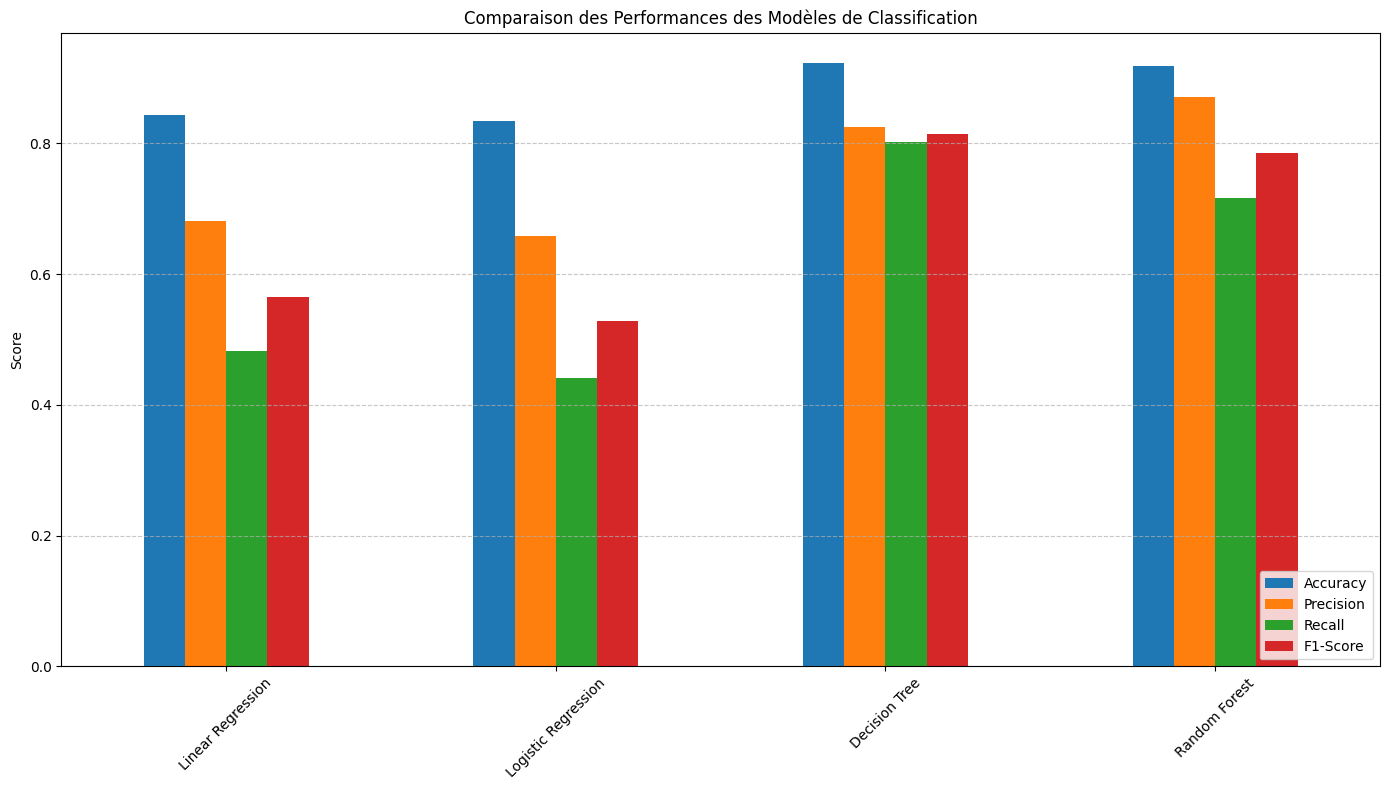

In [42]:
results_df = pd.DataFrame(model_results).T
print("Tableau comparatif des performances des modèles:")
display(results_df)

# Visualisation des performances
results_df.plot(kind='bar', figsize=(14, 8))
plt.title('Comparaison des Performances des Modèles de Classification')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 7. Matrices de Confusion

Les matrices de confusion fournissent une vue détaillée des performances de chaque modèle en montrant les vrais positifs, les vrais négatifs, les faux positifs et les faux négatifs.

Matrices de Confusion pour chaque modèle:


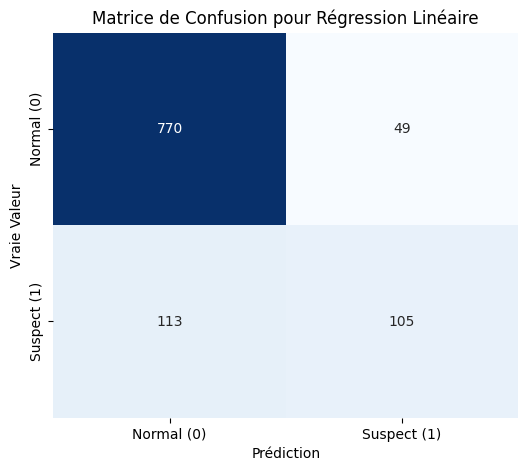

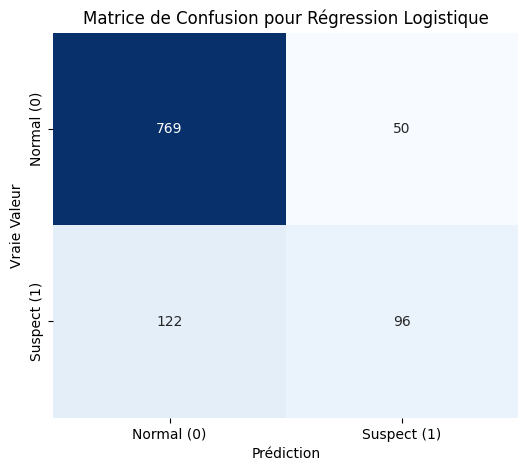

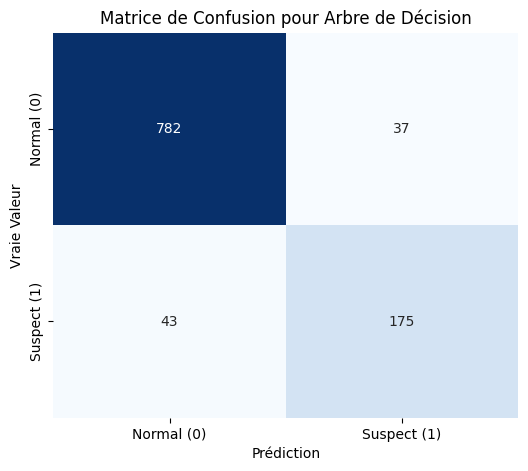

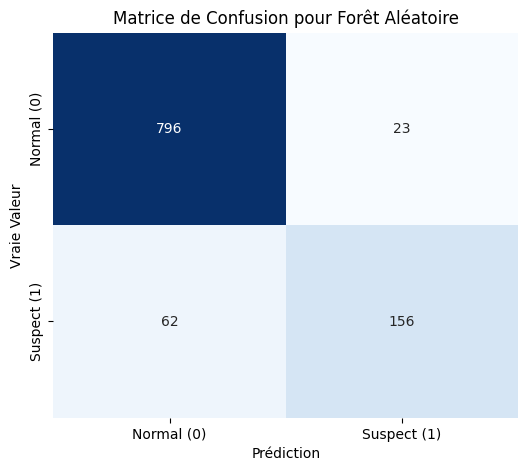

In [43]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Normal (0)', 'Suspect (1)'],
                yticklabels=['Normal (0)', 'Suspect (1)'])
    plt.title(f'Matrice de Confusion pour {model_name}')
    plt.xlabel('Prédiction')
    plt.ylabel('Vraie Valeur')
    plt.show()

print("Matrices de Confusion pour chaque modèle:")
plot_confusion_matrix(y_test, y_pred_lr_binary, 'Régression Linéaire')
plot_confusion_matrix(y_test, y_pred_log_reg, 'Régression Logistique')
plot_confusion_matrix(y_test, y_pred_dt, 'Arbre de Décision')
plot_confusion_matrix(y_test, y_pred_rf, 'Forêt Aléatoire')

## 8. Conclusion et Prochaines Étapes

À ce stade, nous avons entraîné et évalué plusieurs modèles de classification. Le modèle avec les meilleures métriques (par exemple, un équilibre entre précision et rappel, ou un F1-Score élevé, en fonction de l'importance des faux positifs/négatifs dans le contexte de la fraude) serait sélectionné pour le déploiement.

**Prochaines Étapes Possibles :**
*   **Optimisation des hyperparamètres :** Utilisation de GridSearchCV ou RandomizedSearchCV pour affiner les modèles.
*   **Analyse d'importance des caractéristiques :** Identifier les caractéristiques les plus influentes pour le modèle choisi.
*   **Déploiement du modèle :** Intégrer le modèle sélectionné dans une application ou un service pour la détection en temps réel.

## 9. Guide de Déploiement du Modèle

Pour déployer un modèle de Machine Learning, plusieurs étapes sont généralement nécessaires. Nous allons nous concentrer sur le modèle `RandomForestClassifier` (`rf_model`) car il a montré les meilleures performances.

### 9.1. Sauvegarde du Modèle Entraîné et du Scaler

Il est crucial de sauvegarder à la fois le modèle entraîné et le `StandardScaler` utilisé pour la mise à l'échelle des caractéristiques. Le scaler doit être appliqué de la même manière aux nouvelles données avant de les passer au modèle pour la prédiction.

In [ ]:
import joblib

# Chemin pour sauvegarder les objets
model_filename = '/content/drive/MyDrive/Colab Notebooks/random_forest_model.pkl'
scaler_filename = '/content/drive/MyDrive/Colab Notebooks/scaler.pkl'

# Sauvegarder le modèle
joblib.dump(rf_model, model_filename)
print(f"Modèle Random Forest sauvegardé sous : {model_filename}")

# Sauvegarder le scaler
joblib.dump(scaler, scaler_filename)
print(f"Scaler sauvegardé sous : {scaler_filename}")

### 9.2. Chargement du Modèle et du Scaler pour la Prédiction

Dans un environnement de production, vous chargeriez ces objets pour effectuer des prédictions.

In [ ]:
# Charger le modèle et le scaler (exemple pour la production)
loaded_rf_model = joblib.load(model_filename)
loaded_scaler = joblib.load(scaler_filename)

print("Modèle et Scaler chargés avec succès.")

### 9.3. Fonction de Prédiction pour les Nouvelles Données

Cette fonction simule la réception de nouvelles données de transaction et applique le même prétraitement et la prédiction que lors de l'entraînement.

In [ ]:
def predict_new_transaction(new_data_df, model, scaler, original_df_columns):
    # Assurez-vous que les colonnes de `new_data_df` correspondent à `X_train`
    # avant d'appliquer le scaler.

    # 1. Ingénierie des caractéristiques temporelles (si la date est présente)
    if 'Date' in new_data_df.columns:
        new_data_df['Date'] = pd.to_datetime(new_data_df['Date'], errors='coerce')
        new_data_df['DayOfWeek'] = new_data_df['Date'].dt.dayofweek
        new_data_df['Month'] = new_data_df['Date'].dt.month

    # 2. Encodage One-Hot pour les colonnes catégorielles
    categorical_cols_for_pred = ['Type de transaction', 'Status operation', 'Localisation']
    new_data_df = pd.get_dummies(new_data_df, columns=categorical_cols_for_pred, drop_first=True)

    # S'assurer que toutes les colonnes présentes dans X_train sont présentes dans new_data_df
    # et dans le même ordre. Ajouter les colonnes manquantes avec des zéros.
    missing_cols = set(original_df_columns) - set(new_data_df.columns)
    for c in missing_cols:
        new_data_df[c] = False # Ou 0 pour les colonnes numériques qui pourraient manquer

    # Garder l'ordre des colonnes du jeu d'entraînement
    new_data_df = new_data_df[original_df_columns]

    # 3. Mise à l'échelle des caractéristiques numériques
    scaled_data = scaler.transform(new_data_df)

    # 4. Prédiction
    prediction = model.predict(scaled_data)

    return 'Suspect' if prediction[0] == 1 else 'Normal'

print("Fonction de prédiction définie.")

### 9.4. Exemple d'Utilisation de la Fonction de Prédiction

Créons un exemple de nouvelle transaction pour tester la fonction.

In [ ]:
# Exemple de nouvelle transaction (similaire à une ligne de notre DataFrame original après la division initiale)
# Notez que 'Target' n'est pas inclus car c'est ce que nous voulons prédire.
new_transaction_data = {
    'Numero de compte': [851000.0],
    'Type de transaction': ['Paiement en ligne'],
    'Status operation': ['Validé'],
    'Localisation': ['Dakar'],
    'Date': ['2025-03-15 10:00:00'],
    'Montant': [75000.0]
}

new_transaction_df = pd.DataFrame(new_transaction_data)

# Obtenir l'ordre des colonnes utilisé lors de l'entraînement (issues de X)
original_X_columns = X.columns.tolist()

predicted_status = predict_new_transaction(new_transaction_df.copy(), loaded_rf_model, loaded_scaler, original_X_columns)
print(f"La transaction est prédite comme : {predicted_status}")

### 9.5. Considérations Générales de Déploiement

*   **Environnement de Production :** Pour un déploiement réel, vous utiliseriez des plateformes comme Google Cloud AI Platform, AWS SageMaker, Azure Machine Learning, ou des services de conteneurisation (Docker, Kubernetes) pour héberger votre modèle en tant qu'API.
*   **Surveillance du Modèle :** Il est essentiel de surveiller les performances du modèle en production (dérive des données, dérive du concept) et de le ré-entraîner périodiquement.
*   **Intégration :** Le modèle serait intégré dans une application existante qui lui enverrait les données de transaction et recevrait la prédiction.
*   **Latence et Scalabilité :** Pour les transactions bancaires, une faible latence et une haute scalabilité sont cruciales, ce qui influencerait le choix de la plateforme de déploiement et l'architecture.

# Pipeline d'Analyse de Transactions Bancaires - Détection de Fraude

Ce notebook présente un pipeline complet pour l'analyse des transactions bancaires et la détection de transactions suspectes ('fraude') à l'aide de plusieurs modèles de Machine Learning. Le processus inclut le chargement des données, le prétraitement, l'ingénierie des caractéristiques, l'entraînement et l'évaluation de différents modèles de classification.

## 1. Importations Nécessaires

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, mean_squared_error, r2_score

## 2. Chargement des Données

Nous allons monter Google Drive pour accéder au fichier CSV de transactions bancaires et le charger dans un DataFrame pandas.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Bank_transaction_scenario1.csv'
df = pd.read_csv(file_path)

print("Aperçu des 5 premières lignes du DataFrame original:")
display(df.head())
print("\nInformations générales sur le DataFrame original:")
df.info()
print("\nStatistiques descriptives du DataFrame original:")
display(df.describe(include='all'))
print("\nNombre de valeurs manquantes par colonne dans le DataFrame original:")
display(df.isnull().sum())

Aperçu des 5 premières lignes du DataFrame original:


,ID Clients;Numero de compte;Identifiant operation;Type de transaction;Status operation;Localisation;Date;Montant;Target
0,1023;851032.0;TR208/1145;Paiement en ligne;Ech...
1,543;85453.0;TR107/0124;ATM;Echoué;Tambacounda;...
2,1013;851301.0;TR205/00196;Paiement électroniqu...
3,10360;8501036.0;TR216/00239;ATM;Validé;Kaolack...
4,1022;851202.0;TR208/0023;ATM;Validé;Ziguinchor...



Informations générales sur le DataFrame original:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5382 entries, 0 to 5381
Data columns (total 1 columns):
 #   Column                                                                                                                   Non-Null Count  Dtype 
---  ------                                                                                                                   --------------  ----- 
 0   ID Clients;Numero de compte;Identifiant operation;Type de transaction;Status operation;Localisation;Date;Montant;Target  5382 non-null   object
dtypes: object(1)
memory usage: 42.2+ KB

Statistiques descriptives du DataFrame original:


,ID Clients;Numero de compte;Identifiant operation;Type de transaction;Status operation;Localisation;Date;Montant;Target
count,5382
unique,5382
top,507;85705.0;TR2/00510033;Paiement en ligne;Val...
freq,1



Nombre de valeurs manquantes par colonne dans le DataFrame original:


,0
ID Clients;Numero de compte;Identifiant operation;Type de transaction;Status operation;Localisation;Date;Montant;Target,0


## 3. Prétraitement des Données

Cette section gère la transformation des données brutes en un format adapté à l'entraînement des modèles de Machine Learning. Cela inclut la division des colonnes combinées, la conversion des types de données, l'ingénierie de nouvelles caractéristiques et l'encodage des variables catégorielles.

In [4]:
# Diviser la colonne combinée en plusieurs colonnes
df_split = df['ID Clients;Numero de compte;Identifiant operation;Type de transaction;Status operation;Localisation;Date;Montant;Target'].str.split(';', expand=True)
df_split.columns = ['ID Clients', 'Numero de compte', 'Identifiant operation', 'Type de transaction', 'Status operation', 'Localisation', 'Date', 'Montant', 'Target']
df = df_split.copy()

print("Aperçu des données après division des colonnes:")
display(df.head())

Aperçu des données après division des colonnes:


,ID Clients,Numero de compte,Identifiant operation,Type de transaction,Status operation,Localisation,Date,Montant,Target
0,1023,851032.0,TR208/1145,Paiement en ligne,Echoué,Kaolack,2025-02-10 22:20:00,45000.0,Normal
1,543,85453.0,TR107/0124,ATM,Echoué,Tambacounda,2025-02-10 17:00:00,18000.0,Suspect
2,1013,851301.0,TR205/00196,Paiement électronique,Validé,Thiès,2025-02-10 03:30:00,200000.0,Normal
3,10360,8501036.0,TR216/00239,ATM,Validé,Kaolack,2025-02-09 09:00:00,29000.0,Normal
4,1022,851202.0,TR208/0023,ATM,Validé,Ziguinchor,2025-02-08 15:55:00,14000.0,Normal


In [5]:
# Convertir les colonnes numériques
df['Numero de compte'] = pd.to_numeric(df['Numero de compte'], errors='coerce')
df['Montant'] = pd.to_numeric(df['Montant'], errors='coerce')
df['ID Clients'] = pd.to_numeric(df['ID Clients'], errors='coerce')

# Encoder la colonne 'Target' (variable dépendante) en numérique
df['Target'] = df['Target'].map({'Normal': 0, 'Suspect': 1})

print("Types de données après conversion:")
df.info()

Types de données après conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5382 entries, 0 to 5381
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID Clients             5382 non-null   int64  
 1   Numero de compte       5382 non-null   float64
 2   Identifiant operation  5382 non-null   object 
 3   Type de transaction    5382 non-null   object 
 4   Status operation       5382 non-null   object 
 5   Localisation           5382 non-null   object 
 6   Date                   5382 non-null   object 
 7   Montant                5382 non-null   float64
 8   Target                 5184 non-null   float64
dtypes: float64(3), int64(1), object(5)
memory usage: 378.6+ KB


In [6]:
# Ingénierie des caractéristiques temporelles à partir de la colonne 'Date'
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['DayOfWeek'] = df['Date'].dt.dayofweek # Lundi=0, Dimanche=6
df['Month'] = df['Date'].dt.month

# Supprimer la colonne 'Date' originale car les caractéristiques ont été extraites
df = df.drop(columns=['Date'])

print("Aperçu des données avec les nouvelles caractéristiques temporelles:")
display(df.head())

Aperçu des données avec les nouvelles caractéristiques temporelles:


,ID Clients,Numero de compte,Identifiant operation,Type de transaction,Status operation,Localisation,Montant,Target,DayOfWeek,Month
0,1023,851032.0,TR208/1145,Paiement en ligne,Echoué,Kaolack,45000.0,0.0,0,2
1,543,85453.0,TR107/0124,ATM,Echoué,Tambacounda,18000.0,1.0,0,2
2,1013,851301.0,TR205/00196,Paiement électronique,Validé,Thiès,200000.0,0.0,0,2
3,10360,8501036.0,TR216/00239,ATM,Validé,Kaolack,29000.0,0.0,6,2
4,1022,851202.0,TR208/0023,ATM,Validé,Ziguinchor,14000.0,0.0,5,2


In [7]:
# Supprimer les colonnes non pertinentes pour le modèle
df = df.drop(columns=['ID Clients', 'Identifiant operation'])

print("Aperçu des données après suppression des colonnes inutiles:")
display(df.head())

Aperçu des données après suppression des colonnes inutiles:


,Numero de compte,Type de transaction,Status operation,Localisation,Montant,Target,DayOfWeek,Month
0,851032.0,Paiement en ligne,Echoué,Kaolack,45000.0,0.0,0,2
1,85453.0,ATM,Echoué,Tambacounda,18000.0,1.0,0,2
2,851301.0,Paiement électronique,Validé,Thiès,200000.0,0.0,0,2
3,8501036.0,ATM,Validé,Kaolack,29000.0,0.0,6,2
4,851202.0,ATM,Validé,Ziguinchor,14000.0,0.0,5,2


In [8]:
# Gérer les valeurs manquantes en les supprimant (après conversion et extraction de caractéristiques)
df = df.dropna()

print("Nombre de valeurs manquantes après nettoyage:")
display(df.isnull().sum())

Nombre de valeurs manquantes après nettoyage:


,0
Numero de compte,0
Type de transaction,0
Status operation,0
Localisation,0
Montant,0
Target,0
DayOfWeek,0
Month,0


### Encodage des Caractéristiques Catégorielles

Nous utilisons l'encodage One-Hot pour les variables catégorielles afin de les rendre compréhensibles par les modèles de Machine Learning.

In [9]:
categorical_cols = ['Type de transaction', 'Status operation', 'Localisation']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Aperçu des données après encodage One-Hot des caractéristiques catégorielles:")
display(df.head())
print("Informations générales sur le DataFrame final:")
df.info()

Aperçu des données après encodage One-Hot des caractéristiques catégorielles:


,Numero de compte,Montant,Target,DayOfWeek,Month,Type de transaction_Paiement en ligne,Type de transaction_Paiement électronique,Status operation_En attente,Status operation_Validé,Localisation_Bambey,...,Localisation_Saint-Louis,Localisation_Saloum,Localisation_Sédhiou,Localisation_Tambacounda,Localisation_Thiès,Localisation_Tivaouane,Localisation_Touba,Localisation_Toubacouta,Localisation_Vélingara,Localisation_Ziguinchor
0,851032.0,45000.0,0.0,0,2,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,85453.0,18000.0,1.0,0,2,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
2,851301.0,200000.0,0.0,0,2,False,True,False,True,False,...,False,False,False,False,True,False,False,False,False,False
3,8501036.0,29000.0,0.0,6,2,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,851202.0,14000.0,0.0,5,2,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True


Informations générales sur le DataFrame final:
<class 'pandas.core.frame.DataFrame'>
Index: 5184 entries, 0 to 5381
Data columns (total 58 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Numero de compte                           5184 non-null   float64
 1   Montant                                    5184 non-null   float64
 2   Target                                     5184 non-null   float64
 3   DayOfWeek                                  5184 non-null   int32  
 4   Month                                      5184 non-null   int32  
 5   Type de transaction_Paiement en ligne      5184 non-null   bool   
 6   Type de transaction_Paiement électronique  5184 non-null   bool   
 7   Status operation_En attente                5184 non-null   bool   
 8   Status operation_Validé                    5184 non-null   bool   
 9   Localisation_Bambey                        5184 non-nu

## 4. Préparation des Données pour l'Entraînement

Nous divisons les données en ensembles d'entraînement et de test, puis nous mettons à l'échelle les caractéristiques pour que les modèles basés sur la distance ou le gradient fonctionnent correctement.

In [10]:
# Séparer les caractéristiques (X) de la variable cible (y)
X = df.drop('Target', axis=1)
y = df['Target']

print(f"Dimensions de X: {X.shape}")
print(f"Dimensions de y: {y.shape}")

Dimensions de X: (5184, 57)
Dimensions de y: (5184,)


In [11]:
# Diviser les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dimensions de l'ensemble d'entraînement X: {X_train.shape}")
print(f"Dimensions de l'ensemble de test X: {X_test.shape}")
print(f"Proportion de la cible dans y_train:\n{y_train.value_counts(normalize=True)}")
print(f"Proportion de la cible dans y_test:\n{y_test.value_counts(normalize=True)}")

Dimensions de l'ensemble d'entraînement X: (4147, 57)
Dimensions de l'ensemble de test X: (1037, 57)
Proportion de la cible dans y_train:
Target
0.0    0.789486
1.0    0.210514
Name: proportion, dtype: float64
Proportion de la cible dans y_test:
Target
0.0    0.789778
1.0    0.210222
Name: proportion, dtype: float64


In [12]:
# Mettre à l'échelle les caractéristiques numériques
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Caractéristiques mises à l'échelle pour l'entraînement et le test.")

Caractéristiques mises à l'échelle pour l'entraînement et le test.


## 5. Entraînement et Évaluation des Modèles

Nous allons entraîner quatre modèles de classification différents et évaluer leurs performances en utilisant des métriques clés telles que la précision, le rappel, le score F1 et l'exactitude.

In [13]:
model_results = {}

# 1. Modèle de Régression Linéaire (utilisé comme baseline binaire)
# Bien que principalement un modèle de régression, nous binarisons ses prédictions pour l'évaluation de classification.
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train_scaled, y_train)
y_pred_lr = linear_reg_model.predict(X_test_scaled)
y_pred_lr_binary = (y_pred_lr > 0.5).astype(int) # Seuil de 0.5 pour la classification binaire

model_results['Linear Regression'] = {
    'Accuracy': accuracy_score(y_test, y_pred_lr_binary),
    'Precision': precision_score(y_test, y_pred_lr_binary),
    'Recall': recall_score(y_test, y_pred_lr_binary),
    'F1-Score': f1_score(y_test, y_pred_lr_binary)
}
print("Régression Linéaire - Évaluation terminée.")

# 2. Modèle de Régression Logistique
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' est bon pour les petits datasets
log_reg_model.fit(X_train_scaled, y_train)
y_pred_log_reg = log_reg_model.predict(X_test_scaled)

model_results['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, y_pred_log_reg),
    'Precision': precision_score(y_test, y_pred_log_reg),
    'Recall': recall_score(y_test, y_pred_log_reg),
    'F1-Score': f1_score(y_test, y_pred_log_reg)
}
print("Régression Logistique - Évaluation terminée.")

# 3. Modèle d'Arbre de Décision
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

model_results['Decision Tree'] = {
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'Precision': precision_score(y_test, y_pred_dt),
    'Recall': recall_score(y_test, y_pred_dt),
    'F1-Score': f1_score(y_test, y_pred_dt)
}
print("Arbre de Décision - Évaluation terminée.")

# 4. Modèle de Forêt Aléatoire
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

model_results['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-Score': f1_score(y_test, y_pred_rf)
}
print("Forêt Aléatoire - Évaluation terminée.")

Régression Linéaire - Évaluation terminée.
Régression Logistique - Évaluation terminée.
Arbre de Décision - Évaluation terminée.
Forêt Aléatoire - Évaluation terminée.


## 6. Comparaison des Modèles

Nous allons comparer les performances de tous les modèles entraînés pour identifier le plus performant.

Tableau comparatif des performances des modèles:


,Accuracy,Precision,Recall,F1-Score
Linear Regression,0.843780,0.681818,0.481651,0.564516
Logistic Regression,0.834137,0.657534,0.440367,0.527473
Decision Tree,0.922854,0.825472,0.802752,0.813953
Random Forest,0.918033,0.871508,0.715596,0.785894


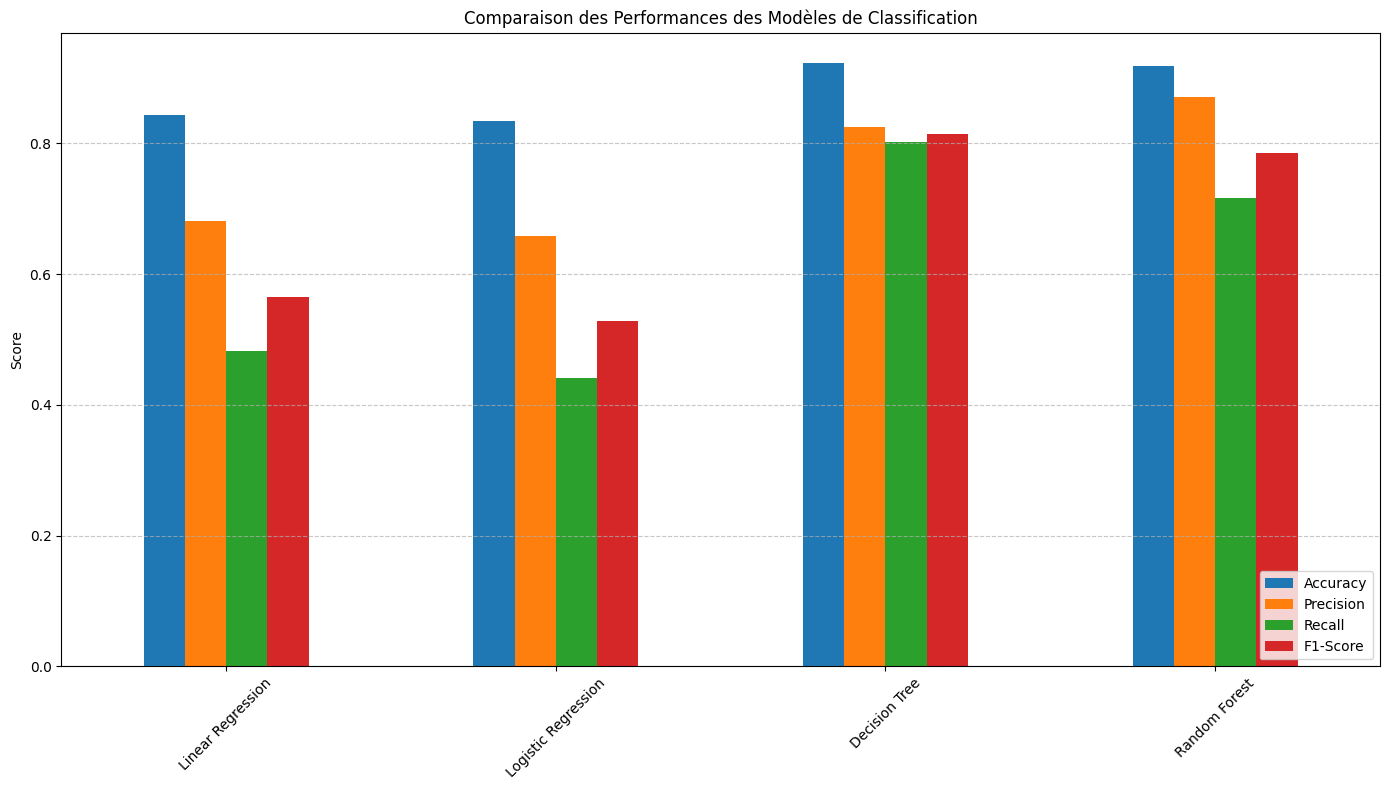

In [14]:
results_df = pd.DataFrame(model_results).T
print("Tableau comparatif des performances des modèles:")
display(results_df)

# Visualisation des performances
results_df.plot(kind='bar', figsize=(14, 8))
plt.title('Comparaison des Performances des Modèles de Classification')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 7. Matrices de Confusion

Les matrices de confusion fournissent une vue détaillée des performances de chaque modèle en montrant les vrais positifs, les vrais négatifs, les faux positifs et les faux négatifs.

Matrices de Confusion pour chaque modèle:


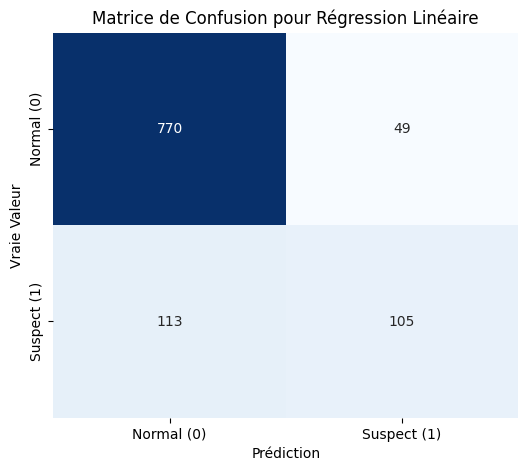

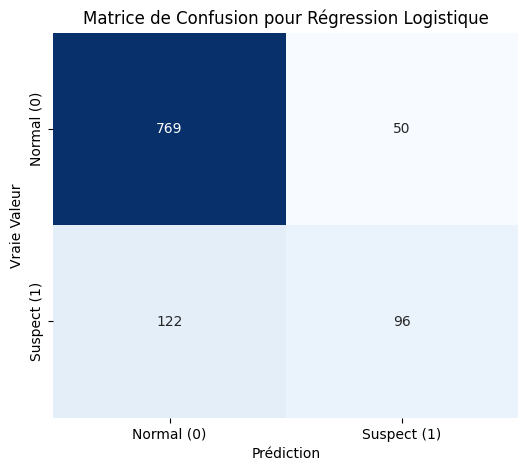

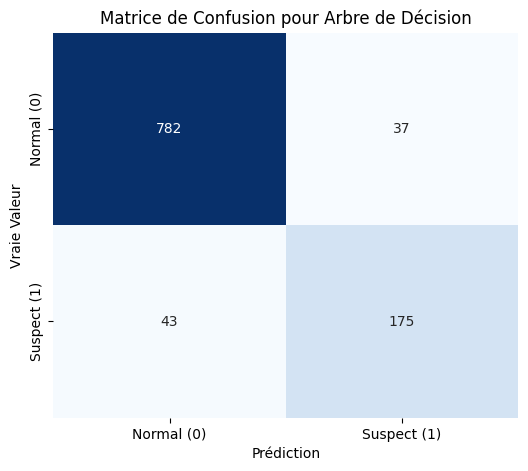

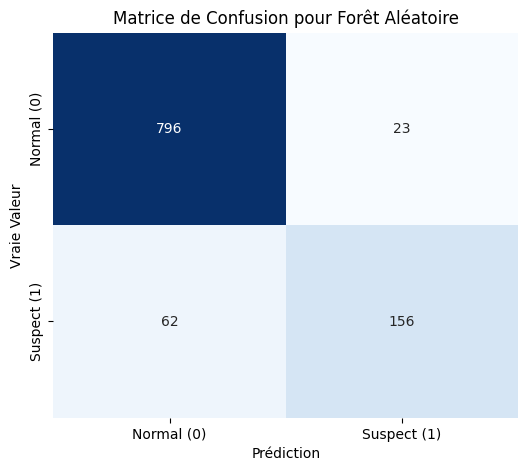

In [15]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Normal (0)', 'Suspect (1)'],
                yticklabels=['Normal (0)', 'Suspect (1)'])
    plt.title(f'Matrice de Confusion pour {model_name}')
    plt.xlabel('Prédiction')
    plt.ylabel('Vraie Valeur')
    plt.show()

print("Matrices de Confusion pour chaque modèle:")
plot_confusion_matrix(y_test, y_pred_lr_binary, 'Régression Linéaire')
plot_confusion_matrix(y_test, y_pred_log_reg, 'Régression Logistique')
plot_confusion_matrix(y_test, y_pred_dt, 'Arbre de Décision')
plot_confusion_matrix(y_test, y_pred_rf, 'Forêt Aléatoire')

## 8. Conclusion et Prochaines Étapes

À ce stade, nous avons entraîné et évalué plusieurs modèles de classification. Le modèle avec les meilleures métriques (par exemple, un équilibre entre précision et rappel, ou un F1-Score élevé, en fonction de l'importance des faux positifs/négatifs dans le contexte de la fraude) serait sélectionné pour le déploiement.

**Prochaines Étapes Possibles :**
*   **Optimisation des hyperparamètres :** Utilisation de GridSearchCV ou RandomizedSearchCV pour affiner les modèles.
*   **Analyse d'importance des caractéristiques :** Identifier les caractéristiques les plus influentes pour le modèle choisi.
*   **Déploiement du modèle :** Intégrer le modèle sélectionné dans une application ou un service pour la détection en temps réel.

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:

df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Bank_transaction_scenario1.csv')

In [19]:
df.describe()

,ID Clients;Numero de compte;Identifiant operation;Type de transaction;Status operation;Localisation;Date;Montant;Target
count,5382
unique,5382
top,507;85705.0;TR2/00510033;Paiement en ligne;Val...
freq,1


In [20]:
df.head()

,ID Clients;Numero de compte;Identifiant operation;Type de transaction;Status operation;Localisation;Date;Montant;Target
0,1023;851032.0;TR208/1145;Paiement en ligne;Ech...
1,543;85453.0;TR107/0124;ATM;Echoué;Tambacounda;...
2,1013;851301.0;TR205/00196;Paiement électroniqu...
3,10360;8501036.0;TR216/00239;ATM;Validé;Kaolack...
4,1022;851202.0;TR208/0023;ATM;Validé;Ziguinchor...


In [21]:
df.isnull().sum()

,0
ID Clients;Numero de compte;Identifiant operation;Type de transaction;Status operation;Localisation;Date;Montant;Target,0


In [22]:
df_split = df['ID Clients;Numero de compte;Identifiant operation;Type de transaction;Status operation;Localisation;Date;Montant;Target'].str.split(';', expand=True)
df_split.columns = ['ID Clients', 'Numero de compte', 'Identifiant operation', 'Type de transaction', 'Status operation', 'Localisation', 'Date', 'Montant', 'Target']
df = df_split.copy()

In [23]:
df = df_split.copy() # Ensure df has the split columns
df['Numero de compte'] = pd.to_numeric(df['Numero de compte'], errors='coerce')
df['Montant'] = pd.to_numeric(df['Montant'], errors='coerce')
df['ID Clients'] = pd.to_numeric(df['ID Clients'], errors='coerce')
df['Target'] = df['Target'].map({'Normal': 0, 'Suspect': 1})

In [24]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Month'] = df['Date'].dt.month
df = df.drop(columns=['Date'])

In [25]:
df = df.drop(columns=['ID Clients', 'Identifiant operation'])

In [26]:
df = df.dropna()

In [27]:
X = df.drop('Target', axis=1)
y = df['Target']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [46]:
y_pred = model.predict(X_test_scaled)

In [47]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 0.11854931063701553
R-squared: 0.2859705076093201


In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


model_results = {}


y_pred_lr_binary = (y_pred > 0.5).astype(int)
model_results['Linear Regression'] = {
    'Accuracy': accuracy_score(y_test, y_pred_lr_binary),
    'Precision': precision_score(y_test, y_pred_lr_binary),
    'Recall': recall_score(y_test, y_pred_lr_binary),
    'F1-Score': f1_score(y_test, y_pred_lr_binary)
}

In [49]:
log_reg_model = LogisticRegression(random_state=42)
log_reg_model.fit(X_train_scaled, y_train)
y_pred_log_reg = log_reg_model.predict(X_test_scaled)

model_results['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, y_pred_log_reg),
    'Precision': precision_score(y_test, y_pred_log_reg),
    'Recall': recall_score(y_test, y_pred_log_reg),
    'F1-Score': f1_score(y_test, y_pred_log_reg)
}

In [50]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

model_results['Decision Tree'] = {
    'Accuracy': accuracy_score(y_test, y_pred_dt),
    'Precision': precision_score(y_test, y_pred_dt),
    'Recall': recall_score(y_test, y_pred_dt),
    'F1-Score': f1_score(y_test, y_pred_dt)
}

In [51]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

model_results['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-Score': f1_score(y_test, y_pred_rf)
}

,Accuracy,Precision,Recall,F1-Score
Linear Regression,0.843780,0.681818,0.481651,0.564516
Logistic Regression,0.834137,0.657534,0.440367,0.527473
Decision Tree,0.922854,0.825472,0.802752,0.813953
Random Forest,0.918033,0.871508,0.715596,0.785894


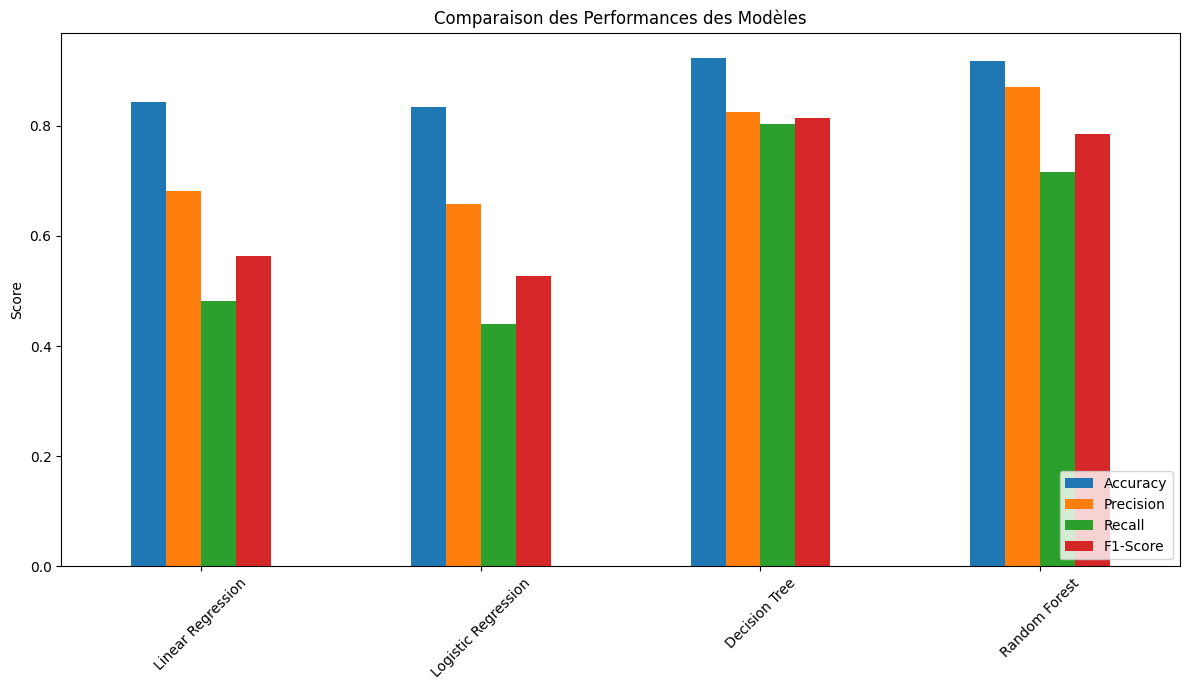

In [52]:
results_df = pd.DataFrame(model_results).T
display(results_df)


results_df.plot(kind='bar', figsize=(12, 7))
plt.title('Comparaison des Performances des Modèles')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

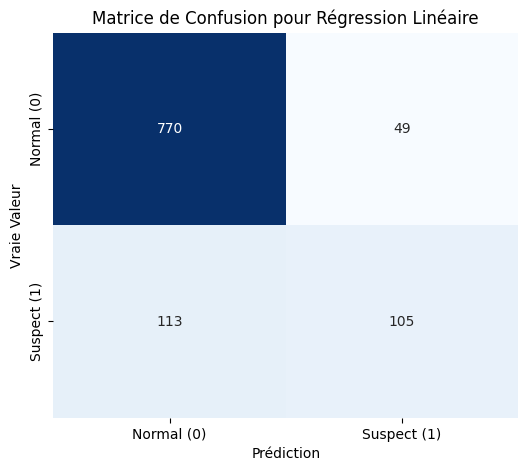

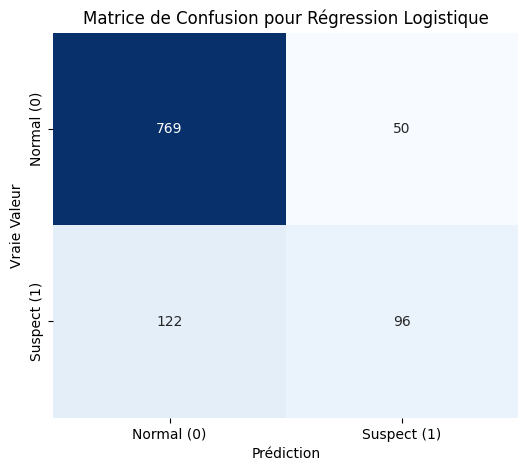

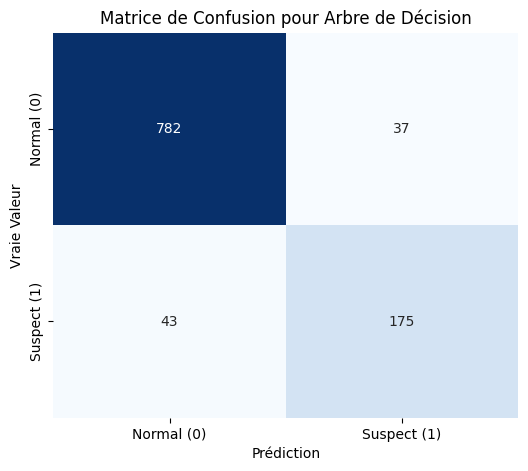

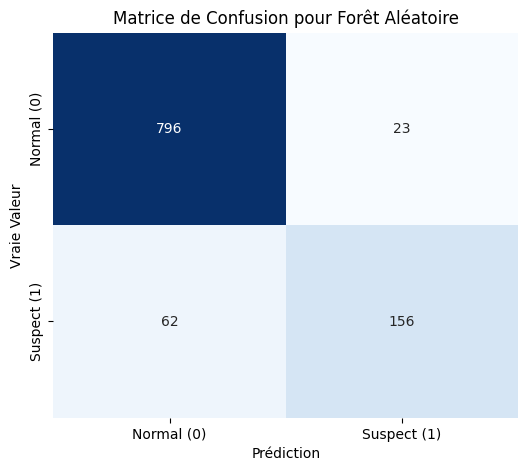

In [53]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Normal (0)', 'Suspect (1)'],
                yticklabels=['Normal (0)', 'Suspect (1)'])
    plt.title(f'Matrice de Confusion pour {model_name}')
    plt.xlabel('Prédiction')
    plt.ylabel('Vraie Valeur')
    plt.show()


plot_confusion_matrix(y_test, y_pred_lr_binary, 'Régression Linéaire')


plot_confusion_matrix(y_test, y_pred_log_reg, 'Régression Logistique')


plot_confusion_matrix(y_test, y_pred_dt, 'Arbre de Décision')

plot_confusion_matrix(y_test, y_pred_rf, 'Forêt Aléatoire')